# Task 1 — Preprocess and Explore the Data

**Assets:** TSLA (Tesla), BND (Vanguard Total Bond Market ETF), SPY (S&P 500 ETF)
**Period:** 2015-01-01 to 2026-06-30
**Goal:** Extract, clean, and explore historical price data to understand trends, volatility,
stationarity, and risk before building any forecasting model.

This notebook calls into the reusable modules in `../src/` (`data_loader.py`, `eda.py`,
`risk_metrics.py`) rather than duplicating logic inline, so the same functions are unit-tested
in `tests/` and importable from `scripts/run_eda.py`.


In [2]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data_loader import (
    fetch_price_data, combine_price_data, clean_price_data,
    add_returns, save_processed, load_and_prepare,
)
from src.eda import (
    add_rolling_stats, detect_outliers_zscore, adf_test, print_adf_result,
    plot_closing_prices, plot_daily_returns, plot_rolling_volatility,
    plot_return_distribution, plot_outliers, plot_correlation_heatmap,
)
from src.risk_metrics import historical_var, parametric_var, sharpe_ratio, summarize_risk

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams["figure.dpi"] = 100


In [1]:
import sys
print(sys.executable)

c:\Users\loolt\portfolio-optimization\venv\Scripts\python.exe


## 1. Extract Historical Financial Data

We pull daily OHLCV data for TSLA, BND, and SPY from YFinance, from 2015-01-01 through
2026-06-30, and combine them into one long-format DataFrame (one row per ticker per date).


In [3]:
TICKERS = ["TSLA", "BND", "SPY"]
START = "2015-01-01"
END = "2026-06-30"

raw_data = fetch_price_data(TICKERS, START, END)
for ticker, df in raw_data.items():
    print(f"{ticker}: {df.shape[0]} rows, {df.index.min().date()} -> {df.index.max().date()}")


TSLA: 2888 rows, 2015-01-02 -> 2026-06-29
BND: 2888 rows, 2015-01-02 -> 2026-06-29
SPY: 2888 rows, 2015-01-02 -> 2026-06-29


In [4]:
combined_raw = combine_price_data(raw_data)
combined_raw.head()


Price,Date,Close,High,Low,Open,Volume,Ticker
0,2015-01-02,59.2056,59.2343,59.0409,59.0481,2218800,BND
1,2015-01-05,59.3776,59.3991,59.2415,59.2701,5820100,BND
2,2015-01-06,59.5495,59.7286,59.4779,59.4779,3887600,BND
3,2015-01-07,59.5854,59.6570,59.4922,59.5567,2433400,BND
4,2015-01-08,59.4922,59.5352,59.4349,59.5352,1873400,BND


## 2. Data Cleaning and Understanding

### 2.1 Basic statistics and data types


In [5]:
combined_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 8664 entries, 0 to 8663
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype        
---  ------  --------------  -----        
 0   Date    8664 non-null   datetime64[s]
 1   Close   8664 non-null   float64      
 2   High    8664 non-null   float64      
 3   Low     8664 non-null   float64      
 4   Open    8664 non-null   float64      
 5   Volume  8664 non-null   int64        
 6   Ticker  8664 non-null   str          
dtypes: datetime64[s](1), float64(4), int64(1), str(1)
memory usage: 473.9 KB


In [6]:
combined_raw.groupby("Ticker")[["Open", "High", "Low", "Close", "Volume"]].describe().T


Ticker                   BND              SPY             TSLA
Price                                                         
Open   count      2,888.0000       2,888.0000       2,888.0000
       mean          66.2834         351.4418         148.7973
       std            4.6998         155.4147         138.9772
       min           58.5607         153.7232           9.4880
       25%           62.2628         223.4746          18.3908
       50%           65.4915         314.1422         131.4963
       75%           70.4512         432.6045         251.6800
       max           74.6396         756.2019         489.8800
High   count      2,888.0000       2,888.0000       2,888.0000
       mean          66.3779         353.3357         151.9906
       std            4.7064         156.1536         141.8528
       min           58.6041         155.2070          10.3313
       25%           62.3264         224.8256          18.6652
       50%           65.6314         315.4914         136.0533
       75%           70.6048         434.9947         257.4850
       max           74.6730         758.4461         498.8300
Low    count      2,888.0000       2,888.0000       2,888.0000
       mean          66.1825         349.3746         145.4167
       std            4.6922         154.5767         135.8672
       min           58.4956         152.0734           9.4033
       25%           62.1953         222.1724          18.0237
       50%           65.3762         310.4947         125.8317
       75%           70.3126         430.3053         245.8325
       max           74.5480         754.8055         485.3300
Close  count      2,888.0000       2,888.0000       2,888.0000
       mean          66.2811         351.5055         148.7739
       std            4.7001         155.4439         138.8960
       min           58.5317         154.1616           9.5780
       25%           62.2680         223.5468          18.3935
       50%           65.5074         312.8179         133.4377
       75%           70.4515         432.8068         251.9258
       max           74.5813         757.6182         489.8800
Volume count      2,888.0000       2,888.0000       2,888.0000
       mean   4,653,785.8033  85,510,494.9792 108,792,194.4598
       std    3,017,703.9497  43,385,532.6469  70,825,493.1529
       min            0.0000  20,270,000.0000  10,620,000.0000
       25%    2,233,700.0000  58,364,550.0000  65,483,250.0000
       50%    4,280,650.0000  75,419,500.0000  90,336,150.0000
       75%    6,246,475.0000  98,822,450.0000 126,120,450.0000
       max   33,963,000.0000 507,244,300.0000 914,082,000.0000

### 2.2 Missing values

In [7]:
missing_summary = combined_raw.groupby("Ticker")[["Open", "High", "Low", "Close", "Volume"]].apply(
    lambda g: g.isna().sum()
)
missing_summary


Price,Open,High,Low,Close,Volume
Ticker,,,,,
BND,0,0,0,0,0
SPY,0,0,0,0,0
TSLA,0,0,0,0,0


**Data quality notes:**
- YFinance data for actively traded ETFs/stocks like TSLA, BND, and SPY is generally complete;
  gaps typically arise only from exchange holidays (already excluded) or occasional data-vendor
  hiccups.
- Any remaining `NaN`s are handled with a per-ticker forward-fill (carrying the last known price
  forward), followed by a backward-fill to cover any leading gap at the very start of the series.
  Forward-fill is preferred over interpolation for price series because it reflects the reality
  that markets were simply closed/no trade occurred, rather than implying a smooth linear glide
  between two prices.
- Numeric columns (`Open`, `High`, `Low`, `Close`, `Volume`) are explicitly cast to numeric types
  to guard against any object-dtype columns coming back from the API.


In [8]:
cleaned = clean_price_data(combined_raw, method="ffill")
print("Remaining NaNs after cleaning:")
print(cleaned[["Open", "High", "Low", "Close", "Volume"]].isna().sum())


Remaining NaNs after cleaning:
Price
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


### 2.3 Add daily returns

In [9]:
cleaned = add_returns(cleaned)
cleaned.tail()


Price,Date,Close,High,Low,Open,Volume,Ticker,Daily_Return,Log_Return
8659,2026-06-23,381.6100,392.8700,379.0600,392.6100,50420200,TSLA,-0.0579,-0.0596
8660,2026-06-24,375.5300,384.5800,373.0500,380.0800,37081400,TSLA,-0.0159,-0.0161
8661,2026-06-25,375.1200,379.1200,371.2200,375.2700,30138800,TSLA,-0.0011,-0.0011
8662,2026-06-26,379.7100,387.8000,368.6000,370.1500,53434100,TSLA,0.0122,0.0122
8663,2026-06-29,411.8400,413.2700,379.3000,381.7900,57645800,TSLA,0.0846,0.0812


### 2.4 Scaling / normalization

For the EDA and classical time-series work below (ADF test, VaR, Sharpe ratio) we keep prices
and returns in their natural units, since scaling would distort interpretability (e.g. a VaR
expressed in standardized units is meaningless to a stakeholder). If a machine-learning model
(e.g. LSTM) is used downstream, features will be scaled with a `MinMaxScaler`/`StandardScaler`
fit **only on the training split** to avoid lookahead bias — that step belongs in the modeling
notebook, not here.


In [11]:
save_processed(cleaned, path="../data/processed/combined_prices.csv")
print("Saved cleaned dataset to ../data/processed/combined_prices.csv")


Saved cleaned dataset to ../data/processed/combined_prices.csv


## 3. Exploratory Data Analysis (EDA)

### 3.1 Closing price over time


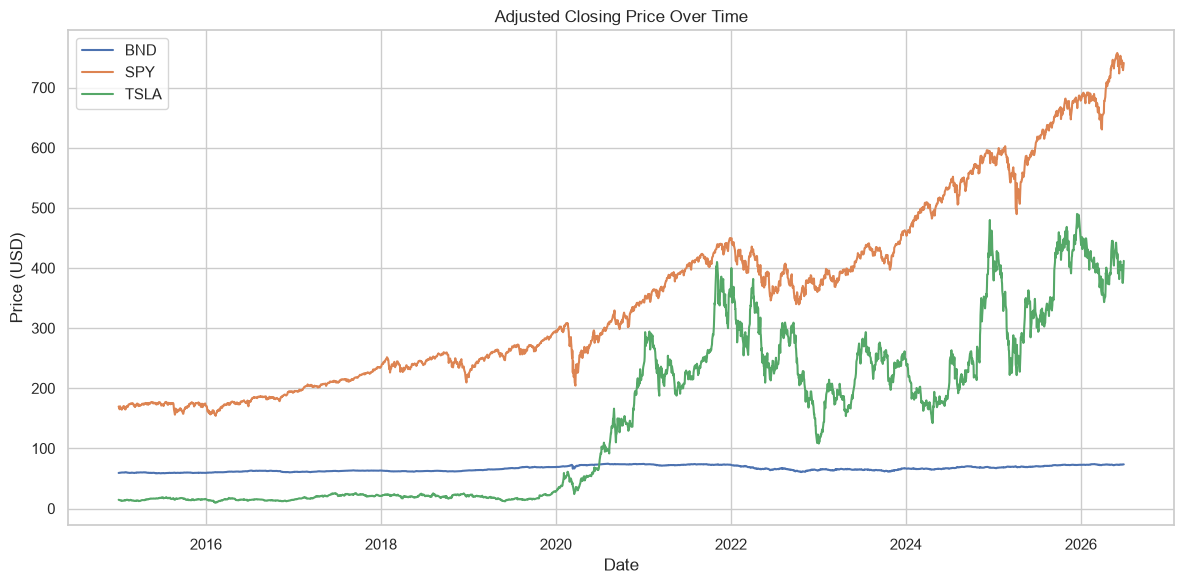

In [12]:
fig = plot_closing_prices(cleaned)
plt.show()


**Observation:** TSLA's price sits on a much higher scale and has grown far more (and far more
erratically) than SPY or BND over the period, which visually compresses the latter two. Plotting
TSLA on its own axis (below) makes its longer-term trend easier to read.


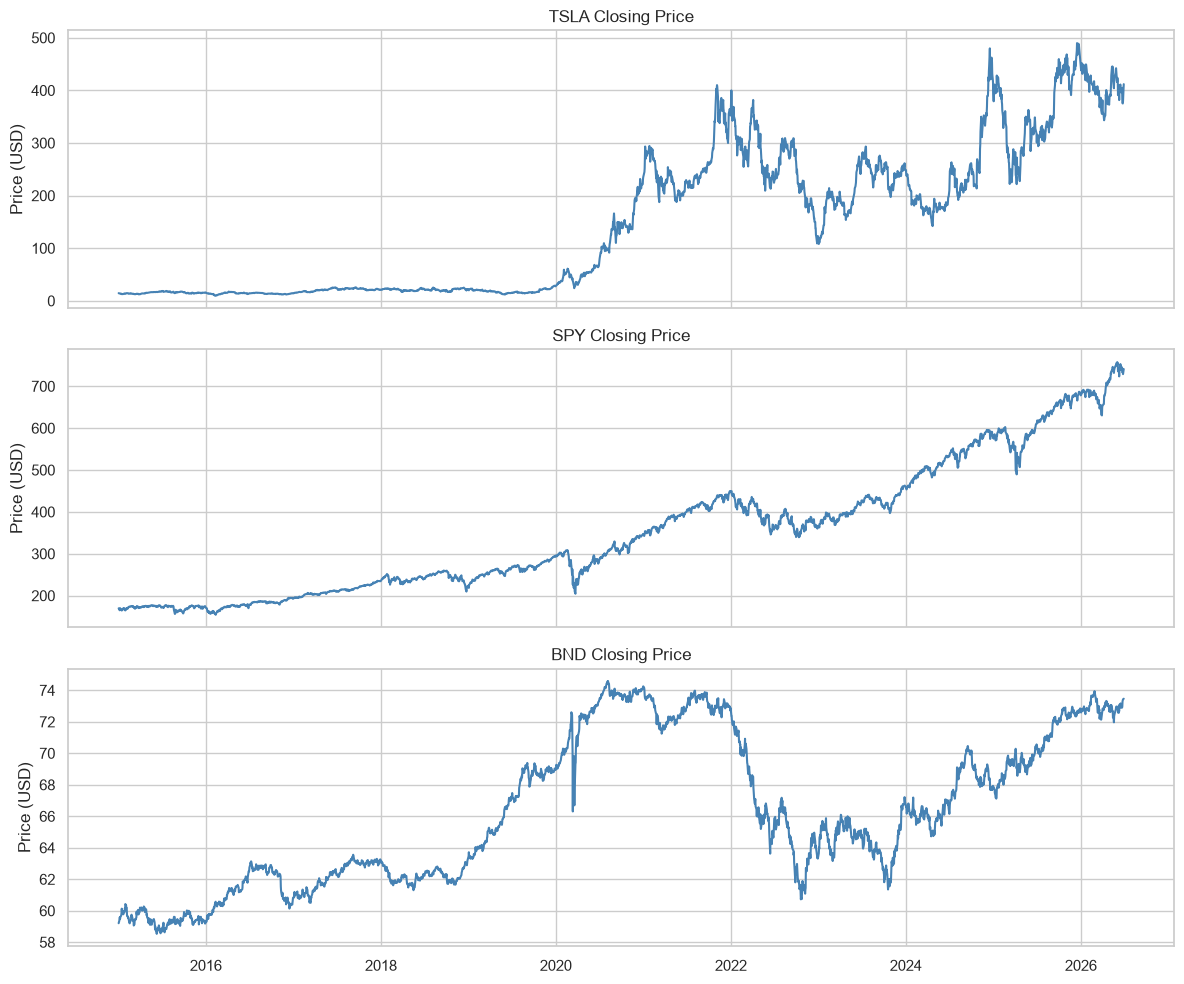

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
for ax, ticker in zip(axes, ["TSLA", "SPY", "BND"]):
    subset = cleaned[cleaned["Ticker"] == ticker]
    ax.plot(subset["Date"], subset["Close"], color="steelblue")
    ax.set_title(f"{ticker} Closing Price")
    ax.set_ylabel("Price (USD)")
plt.tight_layout()
plt.show()


### 3.2 Daily percentage change (volatility)

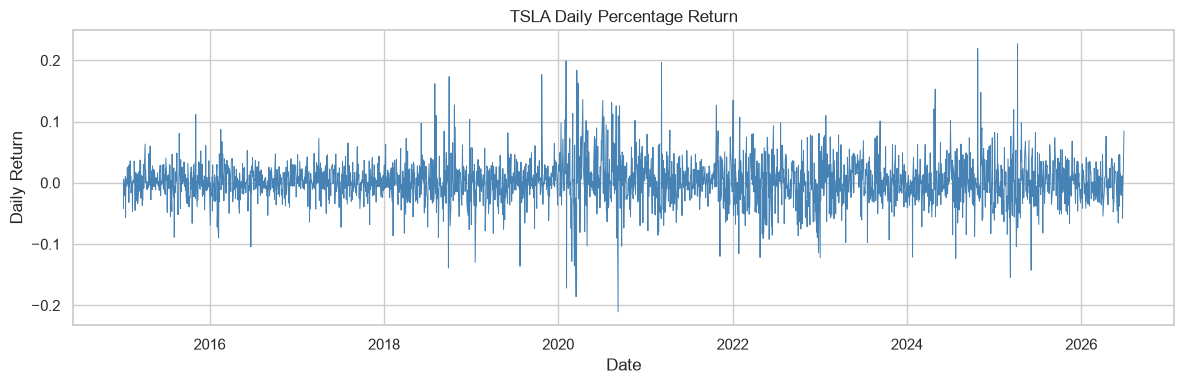

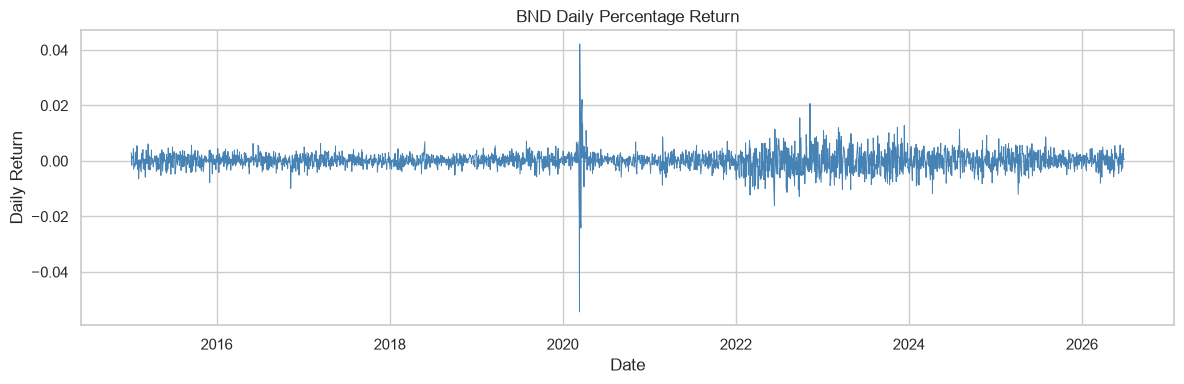

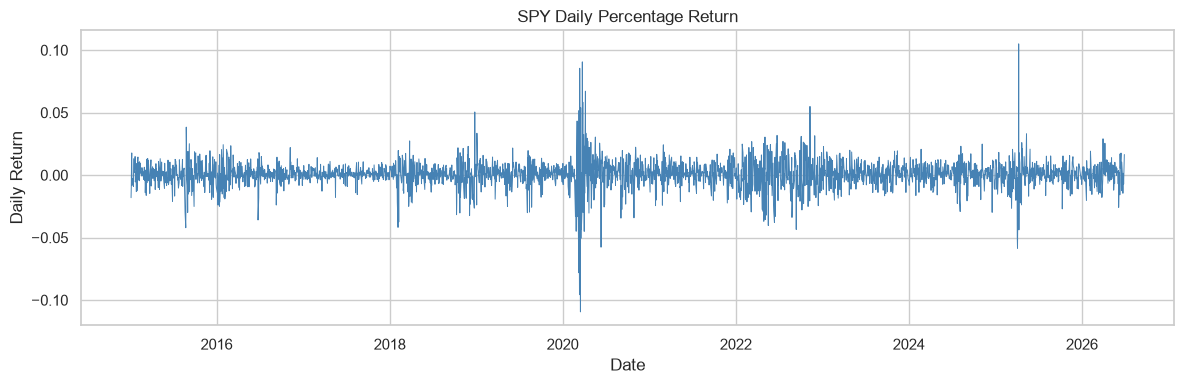

In [14]:
for ticker in TICKERS:
    fig = plot_daily_returns(cleaned, ticker)
    plt.show()


**Observation:** TSLA's daily returns swing far more widely than SPY's, which in turn are
wider than BND's — consistent with TSLA being a high-beta growth stock, SPY a diversified
equity index, and BND a comparatively low-volatility bond fund. Note the visible volatility
clustering (bursts of large moves followed by calmer periods), a hallmark of financial return
series and the motivation for GARCH-family models if volatility forecasting is required later.


### 3.3 Rolling mean and rolling volatility (30-day window)

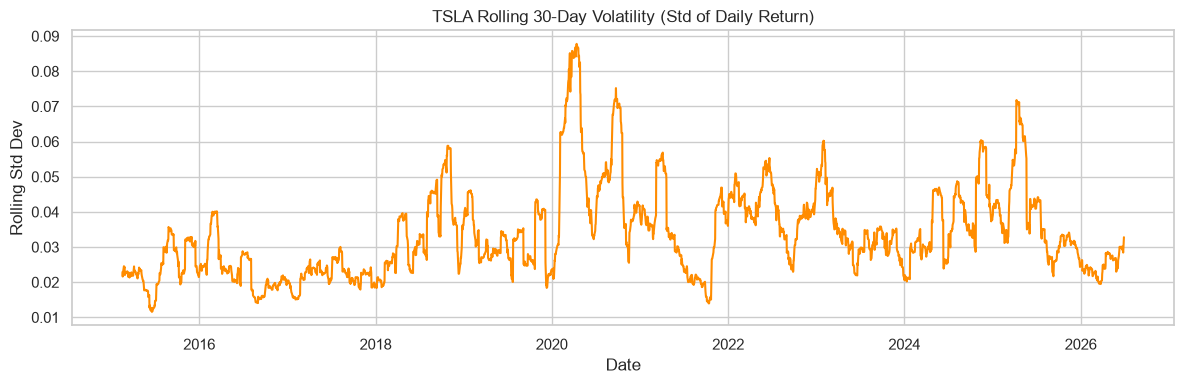

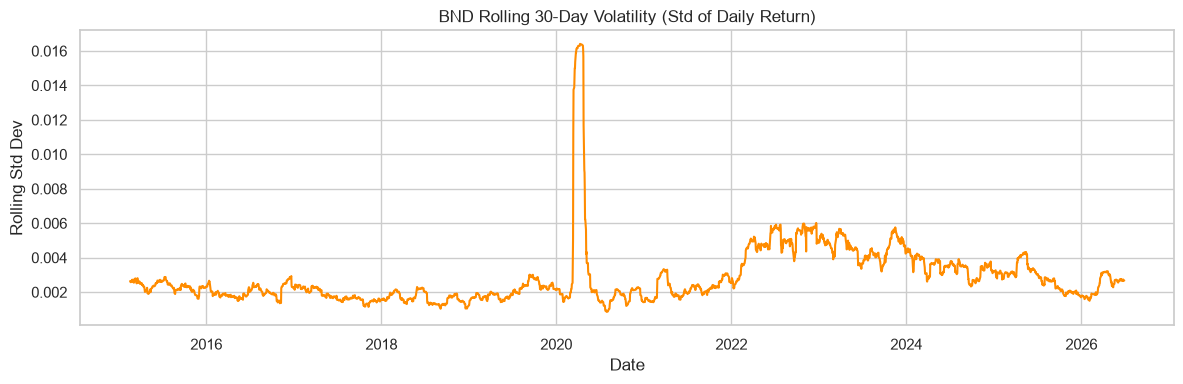

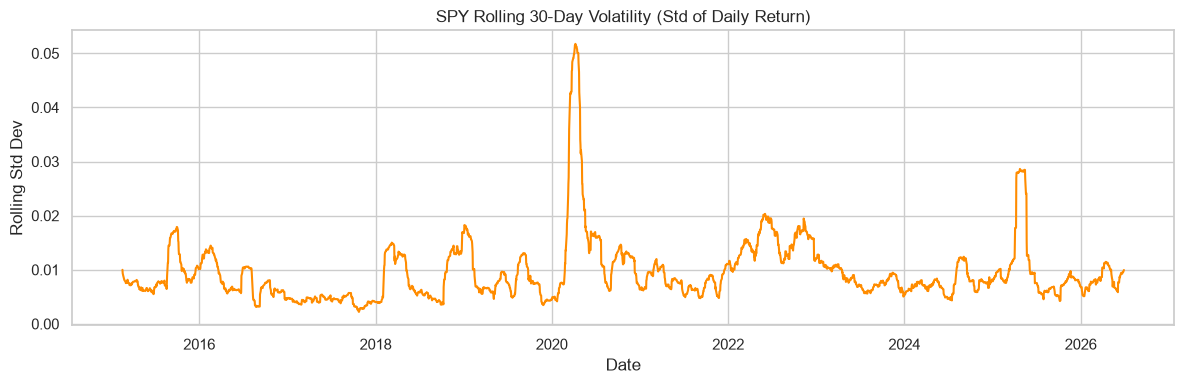

In [15]:
cleaned = add_rolling_stats(cleaned, window=30, col="Daily_Return")

for ticker in TICKERS:
    fig = plot_rolling_volatility(cleaned, ticker, window=30)
    plt.show()


**Observation:** Rolling 30-day volatility spikes sharply around known market stress events
(e.g. the March 2020 COVID crash, the 2022 rate-hiking cycle) across all three assets
simultaneously, while TSLA's *baseline* volatility between shocks still runs persistently higher
than SPY's or BND's — evidence that TSLA carries substantial idiosyncratic risk on top of
market-wide risk.


### 3.4 Distribution of daily returns

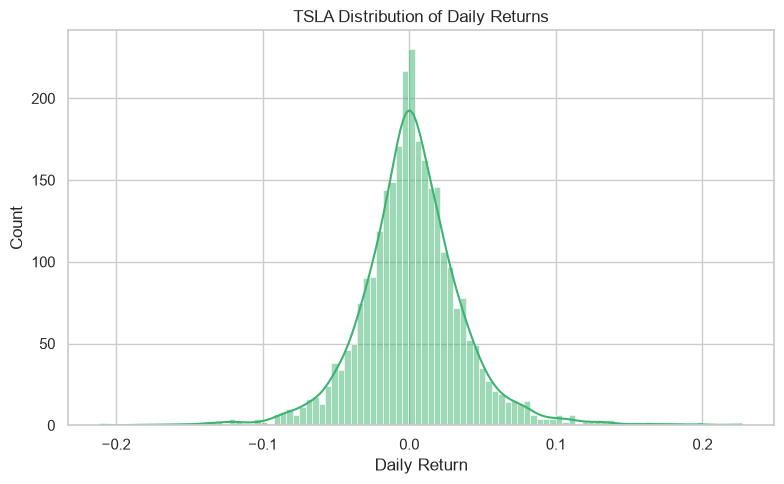

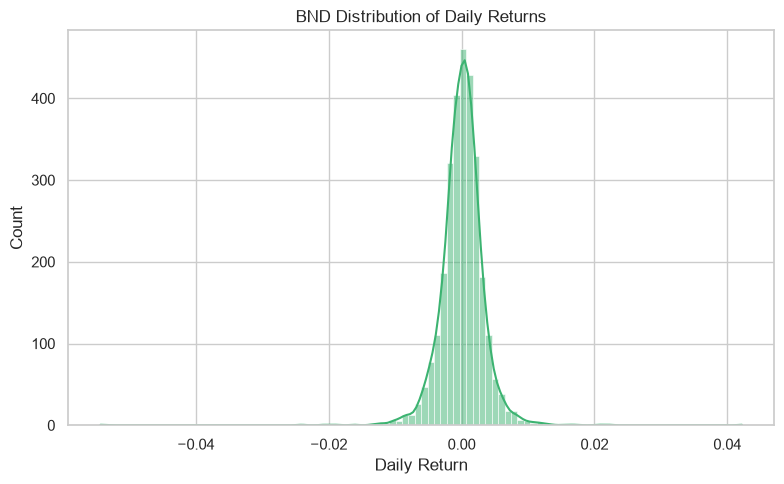

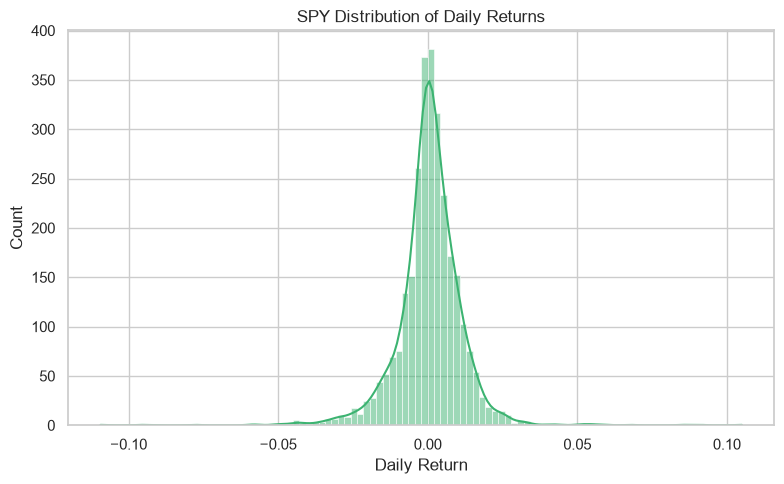

In [16]:
for ticker in TICKERS:
    fig = plot_return_distribution(cleaned, ticker)
    plt.show()


**Observation:** All three return distributions are peaked near zero with visibly fatter tails
than a normal distribution (excess kurtosis) — large moves happen more often than a Gaussian
model would predict. This is why we compute **both** historical (empirical) and parametric
(normal-assumption) VaR below and compare them.


### 3.5 Outlier detection — unusually high/low return days

In [17]:
outliers = detect_outliers_zscore(cleaned, col="Daily_Return", threshold=3.0)
print(f"Total outlier days across all tickers (|z| > 3): {len(outliers)}")
outliers[["Date", "Ticker", "Daily_Return", "Z_Score"]].head(15)


Total outlier days across all tickers (|z| > 3): 118


Price,Date,Ticker,Daily_Return,Z_Score
8358,2025-04-09,TSLA,0.2269,6.2495
8245,2024-10-24,TSLA,0.2192,6.0355
7206,2020-09-08,TSLA,-0.2106,-5.8978
7055,2020-02-03,TSLA,0.1989,5.4735
7331,2021-03-09,TSLA,0.1964,5.4031
7084,2020-03-16,TSLA,-0.1858,-5.2079
7087,2020-03-19,TSLA,0.1839,5.0550
6987,2019-10-24,TSLA,0.1767,4.8556
6719,2018-10-01,TSLA,0.1735,4.7661
7057,2020-02-05,TSLA,-0.1718,-4.8187


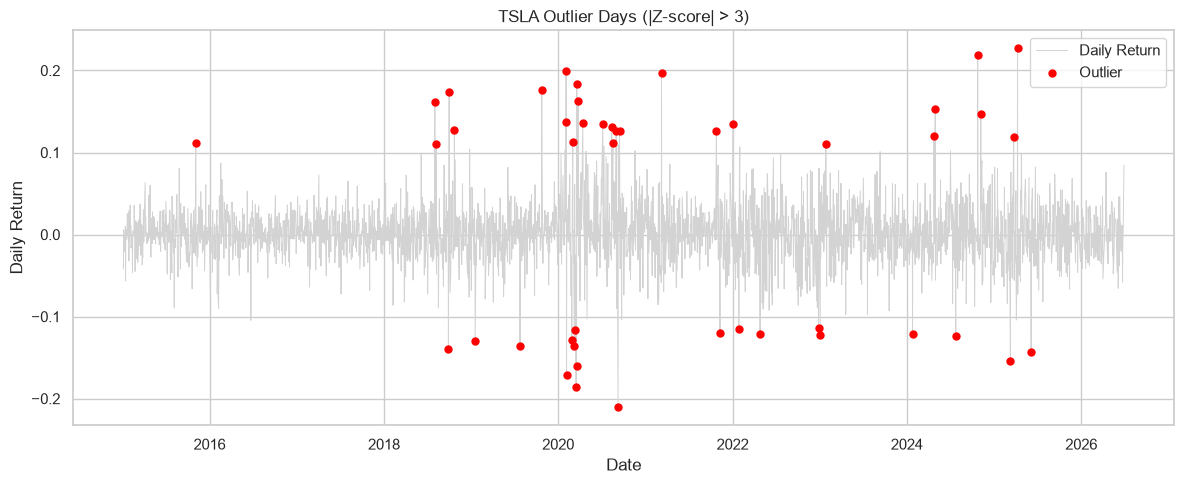

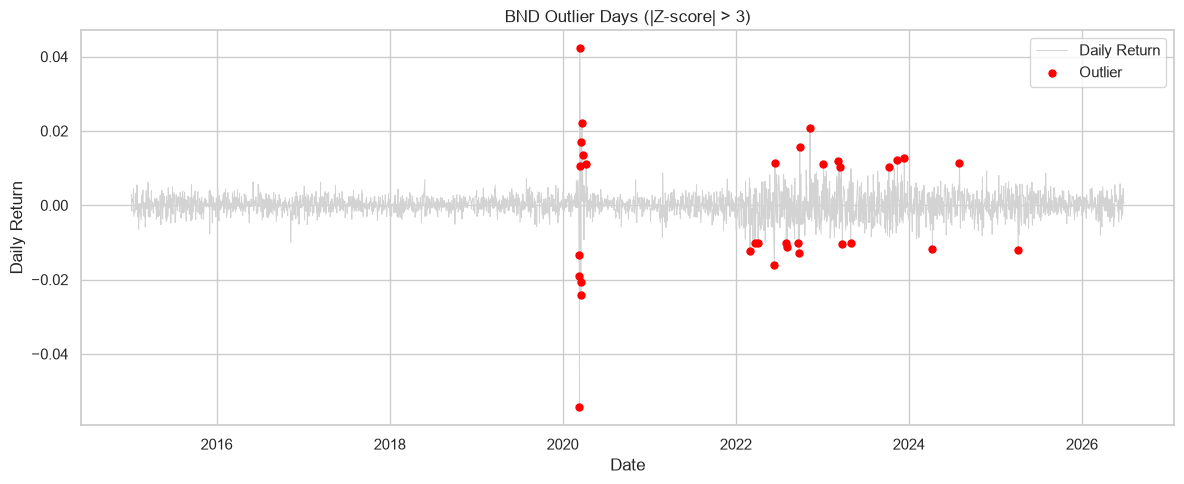

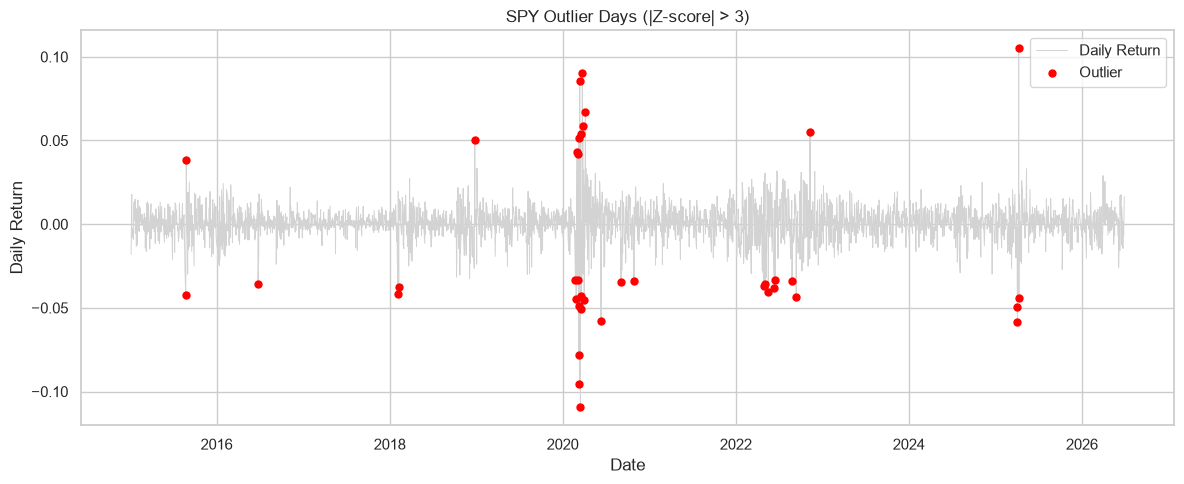

In [18]:
for ticker in TICKERS:
    fig = plot_outliers(cleaned, ticker, outliers)
    plt.show()


In [19]:
print("Top 5 single-day gains and losses per ticker:")
for ticker in TICKERS:
    sub = cleaned[cleaned["Ticker"] == ticker].dropna(subset=["Daily_Return"])
    print(f"\n--- {ticker} ---")
    print("Best days:")
    print(sub.nlargest(5, "Daily_Return")[["Date", "Daily_Return"]].to_string(index=False))
    print("Worst days:")
    print(sub.nsmallest(5, "Daily_Return")[["Date", "Daily_Return"]].to_string(index=False))


Top 5 single-day gains and losses per ticker:

--- TSLA ---
Best days:
      Date  Daily_Return
2025-04-09        0.2269
2024-10-24        0.2192
2020-02-03        0.1989
2021-03-09        0.1964
2020-03-19        0.1839
Worst days:
      Date  Daily_Return
2020-09-08       -0.2106
2020-03-16       -0.1858
2020-02-05       -0.1718
2020-03-18       -0.1603
2025-03-10       -0.1543

--- BND ---
Best days:
      Date  Daily_Return
2020-03-13        0.0422
2020-03-23        0.0221
2022-11-10        0.0207
2020-03-20        0.0170
2022-09-28        0.0155
Worst days:
      Date  Daily_Return
2020-03-12       -0.0544
2020-03-18       -0.0241
2020-03-17       -0.0207
2020-03-11       -0.0189
2022-06-13       -0.0162

--- SPY ---
Best days:
      Date  Daily_Return
2025-04-09        0.1050
2020-03-24        0.0906
2020-03-13        0.0855
2020-04-06        0.0672
2020-03-26        0.0584
Worst days:
      Date  Daily_Return
2020-03-16       -0.1094
2020-03-12       -0.0957
2020-03-09       -0.

**Observation:** TSLA's most extreme days are typically tied to earnings surprises, delivery
numbers, or Elon Musk-related news, while SPY's and BND's extremes cluster around
macroeconomic shocks (COVID-19 crash, rate decisions, banking-sector stress). These anomalies
are legitimate market reactions rather than data errors, so they are flagged for awareness but
**not removed** from the dataset.


### 3.6 Correlation across assets

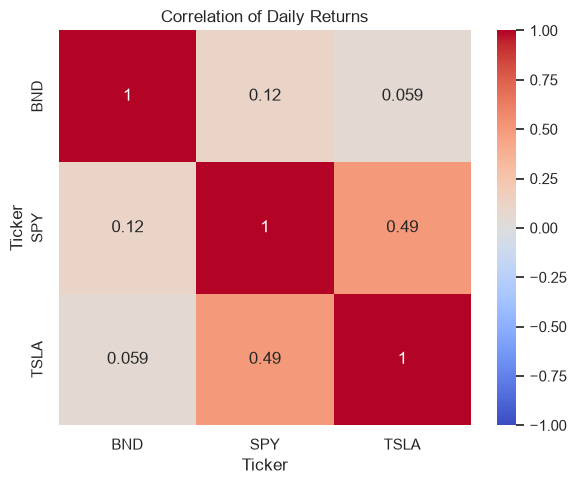

In [20]:
fig = plot_correlation_heatmap(cleaned)
plt.show()


**Observation:** SPY and TSLA typically show a moderate positive correlation (TSLA is a
large-cap constituent of many equity benchmarks, though it also carries substantial
idiosyncratic risk), while BND tends to be weakly or negatively correlated with equities —
exactly the diversification benefit that motivates including a bond ETF in a mixed portfolio.


## 4. Seasonality and Trend Analysis — Augmented Dickey-Fuller (ADF) Test

We test both the **closing price level** and the **daily return** series for each ticker. The
null hypothesis of the ADF test is that the series has a unit root (i.e., is non-stationary).


In [21]:
adf_results = []
for ticker in TICKERS:
    subset = cleaned[cleaned["Ticker"] == ticker]

    price_result = adf_test(subset["Close"], name=f"{ticker} Closing Price")
    print_adf_result(price_result)
    adf_results.append(price_result)

    return_result = adf_test(subset["Daily_Return"], name=f"{ticker} Daily Return")
    print_adf_result(return_result)
    adf_results.append(return_result)


--- ADF Test: TSLA Closing Price ---
ADF Statistic : -1.0696
p-value       : 0.7270
Critical Value (1%) : -3.4326
Critical Value (5%) : -2.8626
Critical Value (10%) : -2.5673
Verdict       : NON-STATIONARY (alpha=0.05)

--- ADF Test: TSLA Daily Return ---
ADF Statistic : -53.9719
p-value       : 0.0000
Critical Value (1%) : -3.4326
Critical Value (5%) : -2.8625
Critical Value (10%) : -2.5673
Verdict       : STATIONARY (alpha=0.05)

--- ADF Test: BND Closing Price ---
ADF Statistic : -1.0479
p-value       : 0.7354
Critical Value (1%) : -3.4326
Critical Value (5%) : -2.8625
Critical Value (10%) : -2.5673
Verdict       : NON-STATIONARY (alpha=0.05)

--- ADF Test: BND Daily Return ---
ADF Statistic : -15.2212
p-value       : 0.0000
Critical Value (1%) : -3.4326
Critical Value (5%) : -2.8625
Critical Value (10%) : -2.5673
Verdict       : STATIONARY (alpha=0.05)

--- ADF Test: SPY Closing Price ---
ADF Statistic : 1.3089
p-value       : 0.9967
Critical Value (1%) : -3.4326
Critical Value (5%

In [22]:
adf_summary = pd.DataFrame([
    {"Series": r["name"], "ADF Statistic": r["ADF_Statistic"], "p-value": r["p_value"], "Stationary (α=0.05)": r["is_stationary"]}
    for r in adf_results
])
adf_summary


,Series,ADF Statistic,p-value,Stationary (α=0.05)
0,TSLA Closing Price,-1.0696,0.7270,False
1,TSLA Daily Return,-53.9719,0.0000,True
2,BND Closing Price,-1.0479,0.7354,False
3,BND Daily Return,-15.2212,0.0000,True
4,SPY Closing Price,1.3089,0.9967,False
5,SPY Daily Return,-17.5722,0.0000,True


**Interpretation:**

- **Closing prices** for all three tickers are expected to be **non-stationary** (p-value well
  above 0.05, ADF statistic above the critical values) — they exhibit trends and a
  time-varying mean, which is typical of raw asset price series. This means models built
  directly on price levels (e.g. plain ARIMA(p,0,q)) would violate the constant-mean/constant-variance
  assumption underlying most classical time-series models.
- **Daily returns**, by contrast, are expected to be **stationary** (p-value well below 0.05) —
  consistent with returns fluctuating around a roughly constant mean with roughly constant
  variance over short windows (though volatility clustering means the *variance* itself is not
  perfectly stationary, motivating GARCH-type extensions if needed).
- **Implication for modeling:** since price levels are non-stationary, the ARIMA family requires
  differencing (the "d" parameter, typically d=1, i.e. modeling returns/price differences rather
  than raw prices) to satisfy stationarity before parameter estimation. This confirms the correct
  approach is either to (a) model the first-differenced/return series directly, or (b) let an
  ARIMA(p,1,q)-style model apply the differencing internally and invert it for forecasts.


## 5. Risk Metrics

We compute foundational risk metrics per ticker:
- **Value at Risk (VaR)** at the 95% confidence level, both historical (empirical) and parametric
  (normal-distribution assumption)
- **Sharpe Ratio**, annualized, using a 2% annual risk-free rate assumption


In [23]:
RISK_FREE_RATE = 0.02
CONFIDENCE = 0.95

risk_summary = summarize_risk(cleaned, confidence=CONFIDENCE, risk_free_rate_annual=RISK_FREE_RATE)
risk_summary


,Annualized_Return,Annualized_Volatility,Historical_VaR_95,Parametric_VaR_95,Sharpe_Ratio
Ticker,,,,,
BND,0.0203,0.0531,0.0048,0.0054,0.0084
SPY,0.1443,0.1765,0.0167,0.0177,0.7053
TSLA,0.4542,0.5718,0.0517,0.0574,0.7598


In [24]:
for ticker in TICKERS:
    r = cleaned[cleaned["Ticker"] == ticker]["Daily_Return"]
    hvar = historical_var(r, CONFIDENCE)
    pvar = parametric_var(r, CONFIDENCE)
    sr = sharpe_ratio(r, RISK_FREE_RATE)
    print(f"{ticker}:")
    print(f"  Historical VaR (95%, 1-day) : {hvar:.4%}  -> on a bad day (1-in-20), expect to lose at least this much")
    print(f"  Parametric VaR (95%, 1-day) : {pvar:.4%}")
    print(f"  Annualized Sharpe Ratio     : {sr:.3f}\n")


TSLA:
  Historical VaR (95%, 1-day) : 5.1664%  -> on a bad day (1-in-20), expect to lose at least this much
  Parametric VaR (95%, 1-day) : 5.7442%
  Annualized Sharpe Ratio     : 0.760

BND:
  Historical VaR (95%, 1-day) : 0.4757%  -> on a bad day (1-in-20), expect to lose at least this much
  Parametric VaR (95%, 1-day) : 0.5424%
  Annualized Sharpe Ratio     : 0.008

SPY:
  Historical VaR (95%, 1-day) : 1.6650%  -> on a bad day (1-in-20), expect to lose at least this much
  Parametric VaR (95%, 1-day) : 1.7720%
  Annualized Sharpe Ratio     : 0.705



**Interpretation:**

- **VaR** answers: "On the worst 5% of days, how much could I expect to lose?" TSLA's VaR is
  materially larger than SPY's, which is in turn larger than BND's — directly reflecting the
  volatility ordering seen in the return distributions above. Historical and parametric VaR
  tend to diverge more for TSLA than for BND, since TSLA's return distribution deviates further
  from normality (fatter tails), so relying purely on the parametric (normal) VaR would
  understate TSLA's true tail risk.
- **Sharpe Ratio** answers: "How much return am I getting per unit of risk taken?" A higher
  Sharpe Ratio indicates better risk-adjusted performance. Comparing the three assets' Sharpe
  Ratios highlights the classic risk/return tradeoff: TSLA has historically offered higher raw
  returns but at a volatility cost that may or may not translate into a superior risk-adjusted
  return, depending on the exact sample period.


## 6. Key Insights Summary

- **Overall direction:** Tesla's stock price has trended strongly upward in the long run across
  2015–2026, but that path was highly non-linear — punctuated by sharp, multi-week drawdowns
  (e.g. around 2018 production concerns, the 2020 COVID crash, and the 2022 rate-hike-driven
  growth-stock selloff) followed by rapid recoveries.
- **Volatility:** TSLA's daily returns are consistently the most volatile of the three assets,
  with visible volatility clustering; SPY sits in the middle as a diversified equity benchmark;
  BND is the most stable, behaving as expected for a bond fund.
- **Stationarity:** Price levels are non-stationary for all three tickers; daily returns are
  stationary. This confirms that any ARIMA-family forecasting model must be applied to
  differenced/return series (or use d=1) rather than raw prices.
- **Tail risk:** TSLA's fat-tailed return distribution means historical (empirical) VaR is a more
  trustworthy estimate of downside risk than the parametric (normal-distribution) VaR, which
  tends to underestimate the likelihood of extreme moves.
- **Diversification:** BND's low/negative correlation with TSLA and SPY supports its inclusion
  in a mixed portfolio as a volatility dampener, which will matter directly in the portfolio
  optimization task that follows.

## Next Steps

With cleaned data, confirmed stationarity properties, and baseline risk metrics in hand, the
next task builds and evaluates ARIMA/SARIMA and LSTM forecasting models on the (differenced)
return series identified as stationary here.
